In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate

### Problem 1

In [2]:
# load feature names, load data, split, scale, and train model
feature_names = []

with open("spambase.names", "r") as f:
    for line in f:
        line = line.strip()

        # keep only actual feature definition lines
        if line.endswith("continuous."):
            feature_names.append(line.split(":")[0].strip())

# add target column name
feature_names.append("spam")

# load dataset with correct column names
data = pd.read_csv("spambase.data", header=None, names=feature_names)

# separate features and target
X = data.drop(columns=["spam"])
y = data["spam"]

# split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# scale features for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# train logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

# predict labels for test data
y_pred = model.predict(X_test_scaled)

# display confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# compute accuracy and error rate
accuracy = accuracy_score(y_test, y_pred)
error = 1 - accuracy

print("\nAccuracy:", accuracy)
print("Error:", error)

# compute precision, recall, and F1 score
print("\nPrecision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Confusion Matrix:
[[650  26]
 [ 63 412]]

Accuracy: 0.9226759339704604
Error: 0.07732406602953956

Precision: 0.9406392694063926
Recall: 0.8673684210526316
F1 Score: 0.9025191675794085


In [3]:
# extract coefficients from trained logistic regression model
coefficients = model.coef_[0]

# map feature names to their coefficients
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": coefficients
})

# print coefficients for all features
print("Feature Coefficients:")
print(coef_df)

# compute absolute magnitude of coefficients
coef_df["AbsCoefficient"] = coef_df["Coefficient"].abs()

# sort by magnitude to find most influential features
top_features = coef_df.sort_values("AbsCoefficient", ascending=False).head(10)

print("\nTop 10 Features Contributing Most to the Prediction:")
print(top_features[["Feature", "Coefficient"]])

# features most positively correlated with spam
print("\nTop Positive Features:")
print(coef_df.sort_values("Coefficient", ascending=False).head(10))

# features most negatively correlated with spam
print("\nTop Negative Features:")
print(coef_df.sort_values("Coefficient").head(10))

Feature Coefficients:
                       Feature  Coefficient
0               word_freq_make    -0.070926
1            word_freq_address    -0.171304
2                word_freq_all     0.066765
3                 word_freq_3d     0.851703
4                word_freq_our     0.407623
5               word_freq_over     0.144011
6             word_freq_remove     0.845988
7           word_freq_internet     0.184297
8              word_freq_order     0.142766
9               word_freq_mail     0.040438
10           word_freq_receive    -0.082289
11              word_freq_will    -0.082218
12            word_freq_people    -0.009349
13            word_freq_report     0.024139
14         word_freq_addresses     0.370550
15              word_freq_free     0.920942
16          word_freq_business     0.401388
17             word_freq_email     0.055335
18               word_freq_you     0.177095
19            word_freq_credit     0.589954
20              word_freq_your     0.287873
21        

In [5]:
# compute predicted probability of spam for each email
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# evaluate model using different decision thresholds
thresholds = [0.25, 0.5, 0.75, 0.9]

print("Threshold Analysis:\n")

for T in thresholds:

    # classify emails as spam if probability exceeds threshold
    y_pred_thresh = (y_prob >= T).astype(int)

    # compute evaluation metrics
    acc = accuracy_score(y_test, y_pred_thresh)
    prec = precision_score(y_test, y_pred_thresh)
    rec = recall_score(y_test, y_pred_thresh)

    print("Threshold:", T)
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print()

Threshold Analysis:

Threshold: 0.25
Accuracy: 0.9122502172024327
Precision: 0.850187265917603
Recall: 0.9557894736842105

Threshold: 0.5
Accuracy: 0.9226759339704604
Precision: 0.9406392694063926
Recall: 0.8673684210526316

Threshold: 0.75
Accuracy: 0.8835794960903562
Precision: 0.9546666666666667
Recall: 0.7536842105263157

Threshold: 0.9
Accuracy: 0.8279756733275413
Precision: 0.9726962457337884
Recall: 0.6



As the decision threshold increases, the model becomes more conservative in classifying emails as spam. At a threshold of 0.25, the model has very high recall because it labels more emails as spam, but this comes with lower precision since more non-spam emails are incorrectly classified as spam. As the threshold increases to 0.5 and 0.75, precision improves because the model becomes more confident before labeling an email as spam, but recall decreases because some spam emails are no longer detected. At 0.9, precision is highest, meaning most predicted spam emails are actually spam, but recall drops significantly and overall accuracy decreases because many spam emails are missed.

### Problem 2

In [6]:
# add bias term to training and testing data
X_train_gd = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_test_gd = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

# convert labels to numpy arrays
y_train_gd = y_train.to_numpy()
y_test_gd = y_test.to_numpy()

# sigmoid function for logistic regression
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# cross-entropy loss function
def cross_entropy_loss(X, y, theta):
    m = len(y)
    h = sigmoid(X @ theta)
    h = np.clip(h, 1e-10, 1 - 1e-10)
    return -(1 / m) * np.sum(y * np.log(h) + (1 - y) * np.log(1 - h))

# gradient descent for logistic regression
def logistic_gradient_descent(X, y, alpha, num_iters):
    m, n = X.shape
    theta = np.zeros(n)
    loss_history = []

    for _ in range(num_iters):
        h = sigmoid(X @ theta)
        gradient = (1 / m) * (X.T @ (h - y))
        theta = theta - alpha * gradient
        loss_history.append(cross_entropy_loss(X, y, theta))

    return theta, loss_history

# predict class labels using a 0.5 threshold
def predict_logistic(X, theta):
    probs = sigmoid(X @ theta)
    return (probs >= 0.5).astype(int)

# learning rates to test
learning_rates = [0.001, 0.01, 0.1]

# report loss after 10, 50, and 100 iterations
print("Cross-Entropy Loss Results:\n")

for alpha in learning_rates:
    theta_10, loss_10 = logistic_gradient_descent(X_train_gd, y_train_gd, alpha, 10)
    theta_50, loss_50 = logistic_gradient_descent(X_train_gd, y_train_gd, alpha, 50)
    theta_100, loss_100 = logistic_gradient_descent(X_train_gd, y_train_gd, alpha, 100)

    print("Learning Rate:", alpha)
    print("Loss after 10 iterations:", loss_10[-1])
    print("Loss after 50 iterations:", loss_50[-1])
    print("Loss after 100 iterations:", loss_100[-1])
    print()

Cross-Entropy Loss Results:

Learning Rate: 0.001
Loss after 10 iterations: 0.6885826014521534
Loss after 50 iterations: 0.671211570607833
Loss after 100 iterations: 0.6513329933914995

Learning Rate: 0.01
Loss after 10 iterations: 0.6511669857747712
Loss after 50 iterations: 0.5416199336398837
Loss after 100 iterations: 0.46873406018219876

Learning Rate: 0.1
Loss after 10 iterations: 0.4653773277352569
Loss after 50 iterations: 0.32412438774423286
Loss after 100 iterations: 0.28907843871268435



In [7]:
# report metrics at 100 iterations for each learning rate
print("Custom Gradient Descent Metrics at 100 Iterations:\n")

for alpha in learning_rates:
    theta, loss_history = logistic_gradient_descent(X_train_gd, y_train_gd, alpha, 100)

    y_train_pred = predict_logistic(X_train_gd, theta)
    y_test_pred = predict_logistic(X_test_gd, theta)

    print("Learning Rate:", alpha)

    print("Training Set:")
    print("Accuracy:", accuracy_score(y_train_gd, y_train_pred))
    print("Precision:", precision_score(y_train_gd, y_train_pred))
    print("Recall:", recall_score(y_train_gd, y_train_pred))
    print("F1 Score:", f1_score(y_train_gd, y_train_pred))

    print("\nTesting Set:")
    print("Accuracy:", accuracy_score(y_test_gd, y_test_pred))
    print("Precision:", precision_score(y_test_gd, y_test_pred))
    print("Recall:", recall_score(y_test_gd, y_test_pred))
    print("F1 Score:", f1_score(y_test_gd, y_test_pred))
    print()

# compare with package logistic regression if model was already trained earlier
print("Package Logistic Regression Comparison:\n")

y_train_pkg = model.predict(X_train_scaled)
y_test_pkg = model.predict(X_test_scaled)

print("Training Set:")
print("Accuracy:", accuracy_score(y_train, y_train_pkg))
print("Precision:", precision_score(y_train, y_train_pkg))
print("Recall:", recall_score(y_train, y_train_pkg))
print("F1 Score:", f1_score(y_train, y_train_pkg))

print("\nTesting Set:")
print("Accuracy:", accuracy_score(y_test, y_test_pkg))
print("Precision:", precision_score(y_test, y_test_pkg))
print("Recall:", recall_score(y_test, y_test_pkg))
print("F1 Score:", f1_score(y_test, y_test_pkg))

Custom Gradient Descent Metrics at 100 Iterations:

Learning Rate: 0.001
Training Set:
Accuracy: 0.8959420289855072
Precision: 0.8607221812822402
Recall: 0.8729446935724963
F1 Score: 0.8667903525046382

Testing Set:
Accuracy: 0.8992180712423979
Precision: 0.881104033970276
Recall: 0.8736842105263158
F1 Score: 0.8773784355179705

Learning Rate: 0.01
Training Set:
Accuracy: 0.8976811594202898
Precision: 0.8733889310083397
Recall: 0.8609865470852018
F1 Score: 0.8671433948061724

Testing Set:
Accuracy: 0.9035621198957429
Precision: 0.9008810572687225
Recall: 0.8610526315789474
F1 Score: 0.8805166846071044

Learning Rate: 0.1
Training Set:
Accuracy: 0.9078260869565218
Precision: 0.9112903225806451
Recall: 0.8445440956651719
F1 Score: 0.8766485647788984

Testing Set:
Accuracy: 0.9061685490877498
Precision: 0.9237875288683602
Recall: 0.8421052631578947
F1 Score: 0.8810572687224669

Package Logistic Regression Comparison:

Training Set:
Accuracy: 0.9257971014492754
Precision: 0.923981191222570

The custom gradient descent model performs reasonably well but is slightly worse than the package logistic regression model. The best custom model (learning rate 0.1) achieved ~0.906 accuracy and ~0.881 F1 score on the testing set, while the package model achieved higher values of ~0.923 accuracy and ~0.903 F1 score. This most likely happens because the package implementation uses more advanced optimization methods and trains until the model converges, while the custom gradient descent was limited to 100 iterations, so it may not have fully converged.

### Problem 3

In [10]:
# candidate k values
k_values = [1, 3, 5, 7, 9, 11, 13, 15]

# 5-fold stratified CV
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for k in k_values:
    knn_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])

    scores = cross_validate(
        knn_pipeline,
        X_train,
        y_train,
        cv=kf,
        scoring=['accuracy', 'precision', 'recall']
    )

    avg_accuracy = scores['test_accuracy'].mean()
    avg_error = 1 - avg_accuracy
    avg_precision = scores['test_precision'].mean()
    avg_recall = scores['test_recall'].mean()

    results.append([k, avg_accuracy, avg_error, avg_precision, avg_recall])

cv_results = pd.DataFrame(
    results,
    columns=['k', 'Accuracy', 'Error', 'Precision', 'Recall']
)

print("Cross-Validation Results for kNN:")
print(cv_results)

best_k = cv_results.loc[cv_results['Error'].idxmin(), 'k']
print("\nBest k based on lowest average validation error:", best_k)

Cross-Validation Results for kNN:
    k  Accuracy     Error  Precision    Recall
0   1  0.894493  0.105507   0.866750  0.860210
1   3  0.900580  0.099420   0.885404  0.854995
2   5  0.896522  0.103478   0.887051  0.840802
3   7  0.899710  0.100290   0.895736  0.840069
4   9  0.895942  0.104058   0.893503  0.831858
5  11  0.895072  0.104928   0.896978  0.825127
6  13  0.895362  0.104638   0.901836  0.819898
7  15  0.893043  0.106957   0.898436  0.816904

Best k based on lowest average validation error: 3


In [13]:
# train final kNN using the best k found from cross validation
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)

# function to compute and print metrics
def print_metrics(name, model):

    # predictions
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    print("\n", name)

    # training metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    print("Training Set:")
    print("Accuracy:", train_acc)
    print("Error:", 1 - train_acc)
    print("Precision:", precision_score(y_train, y_train_pred))
    print("Recall:", recall_score(y_train, y_train_pred))

    # testing metrics
    test_acc = accuracy_score(y_test, y_test_pred)
    print("\nTesting Set:")
    print("Accuracy:", test_acc)
    print("Error:", 1 - test_acc)
    print("Precision:", precision_score(y_test, y_test_pred))
    print("Recall:", recall_score(y_test, y_test_pred))

# print results for all classifiers
print_metrics("Logistic Regression", log_reg)
print_metrics("LDA", lda)
print_metrics("kNN", knn)


 Logistic Regression
Training Set:
Accuracy: 0.9257971014492754
Error: 0.0742028985507246
Precision: 0.9239811912225705
Recall: 0.8811659192825112

Testing Set:
Accuracy: 0.9226759339704604
Error: 0.07732406602953956
Precision: 0.9406392694063926
Recall: 0.8673684210526316

 LDA
Training Set:
Accuracy: 0.8866666666666667
Error: 0.11333333333333329
Precision: 0.9157155399473222
Recall: 0.7795216741405082

Testing Set:
Accuracy: 0.8853171155516942
Error: 0.11468288444830577
Precision: 0.9298245614035088
Recall: 0.7810526315789473

 kNN
Training Set:
Accuracy: 0.9455072463768116
Error: 0.054492753623188395
Precision: 0.9342900302114804
Recall: 0.9245142002989537

Testing Set:
Accuracy: 0.895742832319722
Error: 0.10425716768027804
Precision: 0.880085653104925
Recall: 0.8652631578947368


Based on the results, logistic regression performs the best. It has the highest testing accuracy (~ 0.923) and the highest precision (~ 0.941). Its training and testing metrics are also very similar, which suggests that the model generalizes well and is not strongly overfitting. LDA performs the worst as it has the lowest accuracy on both the training and testing sets (~ 0.887 and ~ 0.885), and it also has the lowest recall, meaning it misses more spam emails compared to the other models. The kNN model performs in between logistic regression and LDA. Its performance is good, but its testing accuracy (~ 0.902) is lower than logistic regression.

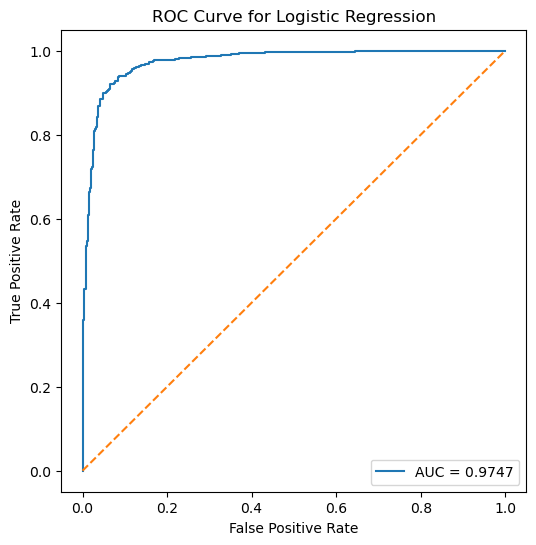

AUC: 0.9747337278106509


In [14]:
# get predicted probabilities for the positive class
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

# compute ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# compute AUC
roc_auc = auc(fpr, tpr)

# plot ROC curve
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

# label axes and title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Logistic Regression")
plt.legend()
plt.show()

# print AUC value
print("AUC:", roc_auc)

Manual ROC Points:
    Threshold  False Positive Rate  True Positive Rate
0         0.0             1.000000            1.000000
1         0.1             0.307692            0.987368
2         0.2             0.152367            0.968421
3         0.3             0.091716            0.938947
4         0.4             0.063609            0.909474
5         0.5             0.038462            0.867368
6         0.6             0.034024            0.829474
7         0.7             0.026627            0.787368
8         0.8             0.022189            0.717895
9         0.9             0.011834            0.600000
10        1.0             0.000000            0.002105


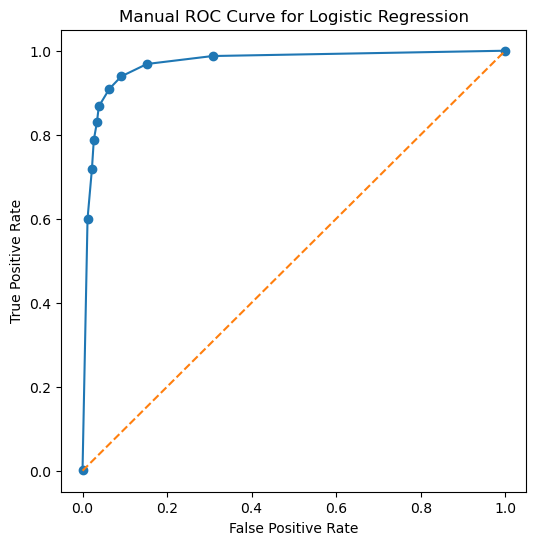

In [15]:
# get predicted probabilities for the positive class (spam)
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

# thresholds given in the problem
thresholds = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]

# store false positive and true positive rates
fpr_list = []
tpr_list = []

# compute FPR and TPR for each threshold
for T in thresholds:

    y_pred_thresh = (y_prob >= T).astype(int)

    tp = ((y_test == 1) & (y_pred_thresh == 1)).sum()
    fn = ((y_test == 1) & (y_pred_thresh == 0)).sum()
    fp = ((y_test == 0) & (y_pred_thresh == 1)).sum()
    tn = ((y_test == 0) & (y_pred_thresh == 0)).sum()

    tpr = tp / (tp + fn)
    fpr = fp / (fp + tn)

    tpr_list.append(tpr)
    fpr_list.append(fpr)

# create table of ROC points
roc_points = pd.DataFrame({
    "Threshold": thresholds,
    "False Positive Rate": fpr_list,
    "True Positive Rate": tpr_list
})

print("Manual ROC Points:")
print(roc_points)

# plot ROC curve from manual points
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.plot(fpr_list, tpr_list, marker="o")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Manual ROC Curve for Logistic Regression")
plt.show()

The ROC curve generated using the package is smoother because it evaluates the classifier at many possible probability thresholds from the predicted probabilities. The manual ROC curve uses only a small fixed set of thresholds (0, 0.1, …, 1), so it contains fewer points and appears more jagged or coarse. Both curves have the same overall shape and show a strong classifier, but the package version is more precise. To make the two curves more similar, we could compute the manual ROC curve using many more thresholds. For example, using all unique predicted probabilities or using a much finer grid of thresholds.

### Problem 4

In [16]:
# choose number of folds
k = 5

# reset row indices so fold slicing is clean
X_cv = X.reset_index(drop=True)
y_cv = y.reset_index(drop=True)

# shuffle the full dataset before creating folds
shuffled_idx = np.random.permutation(len(X_cv))
X_cv = X_cv.iloc[shuffled_idx].reset_index(drop=True)
y_cv = y_cv.iloc[shuffled_idx].reset_index(drop=True)

# compute fold sizes
n = len(X_cv)
fold_size = n // k

# function to run manual k-fold cross-validation
def manual_kfold_cv(model, X, y, k):
    errors = []

    for i in range(k):
        # define validation fold boundaries
        start = i * fold_size
        end = (i + 1) * fold_size if i < k - 1 else n

        # split into validation and training sets
        X_val = X.iloc[start:end]
        y_val = y.iloc[start:end]

        X_train_fold = pd.concat([X.iloc[:start], X.iloc[end:]])
        y_train_fold = pd.concat([y.iloc[:start], y.iloc[end:]])

        # scale each fold using training data only
        scaler = StandardScaler()
        X_train_fold_scaled = scaler.fit_transform(X_train_fold)
        X_val_scaled = scaler.transform(X_val)

        # train model on k-1 folds
        model.fit(X_train_fold_scaled, y_train_fold)

        # predict on validation fold
        y_val_pred = model.predict(X_val_scaled)

        # compute validation error
        val_accuracy = accuracy_score(y_val, y_val_pred)
        val_error = 1 - val_accuracy
        errors.append(val_error)

        print("Fold", i + 1, "Validation Error:", val_error)

    # compute average validation error
    avg_error = np.mean(errors)
    print("Average Validation Error:", avg_error)
    print()

# run manual k-fold CV for logistic regression
print("Logistic Regression Cross-Validation:")
manual_kfold_cv(LogisticRegression(max_iter=1000), X_cv, y_cv, k)

# run manual k-fold CV for LDA
print("LDA Cross-Validation:")
manual_kfold_cv(LinearDiscriminantAnalysis(), X_cv, y_cv, k)

Logistic Regression Cross-Validation:
Fold 1 Validation Error: 0.07173913043478264
Fold 2 Validation Error: 0.07391304347826089
Fold 3 Validation Error: 0.05760869565217386
Fold 4 Validation Error: 0.10978260869565215
Fold 5 Validation Error: 0.06948968512486431
Average Validation Error: 0.07650663267714677

LDA Cross-Validation:
Fold 1 Validation Error: 0.11086956521739133
Fold 2 Validation Error: 0.09891304347826091
Fold 3 Validation Error: 0.10543478260869565
Fold 4 Validation Error: 0.13478260869565217
Fold 5 Validation Error: 0.1129207383279045
Average Validation Error: 0.11258414766558092



In [17]:
# function to run manual k-fold CV and return average validation error
def manual_kfold_avg_error(model, X, y, k):
    # reset indices
    X_cv = X.reset_index(drop=True)
    y_cv = y.reset_index(drop=True)

    # shuffle data before splitting into folds
    shuffled_idx = np.random.permutation(len(X_cv))
    X_cv = X_cv.iloc[shuffled_idx].reset_index(drop=True)
    y_cv = y_cv.iloc[shuffled_idx].reset_index(drop=True)

    n = len(X_cv)
    fold_size = n // k
    errors = []

    for i in range(k):
        # define validation fold
        start = i * fold_size
        end = (i + 1) * fold_size if i < k - 1 else n

        X_val = X_cv.iloc[start:end]
        y_val = y_cv.iloc[start:end]

        X_train_fold = pd.concat([X_cv.iloc[:start], X_cv.iloc[end:]])
        y_train_fold = pd.concat([y_cv.iloc[:start], y_cv.iloc[end:]])

        # scale using training fold only
        scaler = StandardScaler()
        X_train_fold_scaled = scaler.fit_transform(X_train_fold)
        X_val_scaled = scaler.transform(X_val)

        # train and evaluate model
        model.fit(X_train_fold_scaled, y_train_fold)
        y_val_pred = model.predict(X_val_scaled)

        val_error = 1 - accuracy_score(y_val, y_val_pred)
        errors.append(val_error)

    return np.mean(errors)

# values of k to test
k_values = [5, 10]

# run experiments for logistic regression and LDA
for k in k_values:
    log_error = manual_kfold_avg_error(LogisticRegression(max_iter=1000), X, y, k)
    lda_error = manual_kfold_avg_error(LinearDiscriminantAnalysis(), X, y, k)

    print("k =", k)
    print("Logistic Regression Average Validation Error:", log_error)
    print("LDA Average Validation Error:", lda_error)
    print()

k = 5
Logistic Regression Average Validation Error: 0.07455176320634471
LDA Average Validation Error: 0.11258698012557242

k = 10
Logistic Regression Average Validation Error: 0.07520418749410544
LDA Average Validation Error: 0.1149759502027728



Based on the cross-validation results, logistic regression performs better than LDA. Logistic regression has a much lower average validation error for both values of k. For example, with k = 5, logistic regression has an average validation error of ~0.076, while LDA has a higher error of ~0.112. Similarly, with k=10, logistic regression has an average error of ~0.074, compared to ~0.113 for LDA. This shows that logistic regression makes fewer validation mistakes than LDA on this dataset. Increasing the number of folds from 5 to 10 slightly improves the performance of logistic regression, while the performance of LDA remains about the same.